(sp)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`SciPy <single: SciPy>`

```{index} single: Python; SciPy
```

علاوه بر آنچه در Anaconda موجود است، این سخنرانی به کتابخانه‌های زیر نیاز خواهد داشت:

In [1]:
!pip install --upgrade quantecon

ما از import های زیر استفاده می‌کنیم.

In [2]:
import numpy as np
import quantecon as qe

## مروری کلی

[SciPy](https://scipy.org/) بر روی NumPy ساخته شده است تا ابزارهای متداول برای برنامه‌نویسی علمی را فراهم کند، از جمله

* [جبر خطی](https://docs.scipy.org/doc/scipy/reference/linalg.html)
* [انتگرال‌گیری عددی](https://docs.scipy.org/doc/scipy/reference/integrate.html)
* [درون‌یابی](https://docs.scipy.org/doc/scipy/reference/interpolate.html)
* [بهینه‌سازی](https://docs.scipy.org/doc/scipy/reference/optimize.html)
* [توزیع‌ها و تولید اعداد تصادفی](https://docs.scipy.org/doc/scipy/reference/stats.html)
* [پردازش سیگنال](https://docs.scipy.org/doc/scipy/reference/signal.html)
* و غیره، و غیره

همانند NumPy، SciPy پایدار، بالغ و به طور گسترده‌ای استفاده می‌شود.

بسیاری از روال‌های SciPy پوشش‌های نازکی در اطراف کتابخانه‌های استاندارد صنعتی Fortran مانند [LAPACK](https://en.wikipedia.org/wiki/LAPACK)، [BLAS](https://en.wikipedia.org/wiki/Basic_Linear_Algebra_Subprograms) و غیره هستند.

واقعاً نیازی به "یادگیری" SciPy به عنوان یک کل نیست.

رویکرد متداول‌تر این است که ایده‌ای کلی از آنچه در کتابخانه موجود است به دست آورید و سپس در صورت نیاز به [مستندات](https://docs.scipy.org/doc/scipy/reference/index.html) مراجعه کنید.

در این سخنرانی، ما فقط قصد داریم برخی بخش‌های مفید بسته را برجسته کنیم.

## {index}`SciPy <single: SciPy>` در مقابل {index}`NumPy <single: NumPy>`

SciPy بسته‌ای است که حاوی ابزارهای مختلفی است که بر روی NumPy ساخته شده‌اند و از نوع داده آرایه و عملکردهای مرتبط آن استفاده می‌کنند.

````{note} 
در نسخه‌های قدیمی‌تر SciPy (`scipy < 0.15.1`)، import کردن بسته، سمبل‌های NumPy را نیز به فضای نام سراسری import می‌کرد، همانطور که از این گزیده از فایل مقداردهی اولیه SciPy مشخص است:

```python
from numpy import *
from numpy.random import rand, randn
from numpy.fft import fft, ifft
from numpy.lib.scimath import *
```

با این حال، رویه بهتری است که از عملکرد NumPy به صورت صریح استفاده شود.

```python
import numpy as np

a = np.identity(3)
```

نسخه‌های اخیر SciPy (1.15+) دیگر به طور خودکار سمبل‌های NumPy را import نمی‌کنند.
````

آنچه در SciPy مفید است، عملکرد در زیربسته‌های آن است

* `scipy.optimize`، `scipy.integrate`، `scipy.stats` و غیره.

بیایید برخی از زیربسته‌های اصلی را بررسی کنیم.

## آمار

```{index} single: SciPy; Statistics
```

زیربسته `scipy.stats` موارد زیر را ارائه می‌دهد

* اشیاء متغیر تصادفی متعدد (چگالی‌ها، توزیع‌های تجمعی، نمونه‌برداری تصادفی و غیره)
* برخی روش‌های تخمین
* برخی آزمون‌های آماری

### متغیرهای تصادفی و توزیع‌ها

به یاد بیاورید که `numpy.random` ابزارهایی را برای تولید متغیرهای تصادفی فراهم می‌کند

In [3]:
rng = np.random.default_rng()
rng.beta(5, 5, size=3)

array([0.85708222, 0.37269265, 0.69991465])

این یک نمونه از توزیع با تابع چگالی زیر را وقتی `a, b = 5, 5` تولید می‌کند

```{math}
:label: betadist2

f(x; a, b) = \frac{x^{(a - 1)} (1 - x)^{(b - 1)}}
    {\int_0^1 u^{(a - 1)} (1 - u)^{(b - 1)} du}
    \qquad (0 \leq x \leq 1)
```

گاهی اوقات ما نیاز به دسترسی به خود چگالی، یا cdf، چندک‌ها و غیره داریم.

برای این منظور، می‌توانیم از `scipy.stats` استفاده کنیم که تمام این عملکرد و همچنین تولید اعداد تصادفی را در یک رابط سازگار واحد فراهم می‌کند.

این یک مثال از استفاده است

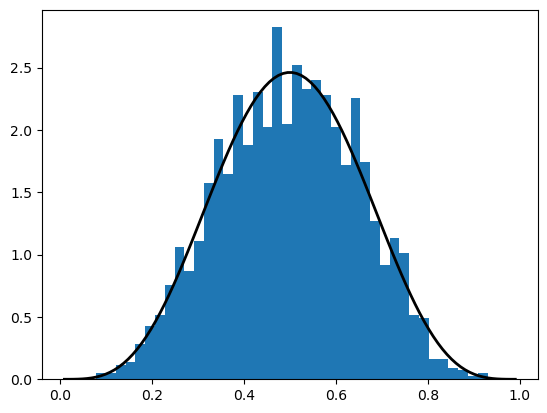

In [4]:
from scipy.stats import beta
import matplotlib.pyplot as plt

q = beta(5, 5)      # Beta(a, b), with a = b = 5
obs = q.rvs(2000)   # 2000 observations
grid = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots()
ax.hist(obs, bins=40, density=True)
ax.plot(grid, q.pdf(grid), 'k-', linewidth=2)
plt.show()

شیء `q` که نماینده توزیع است، متدهای مفید دیگری نیز دارد، از جمله

In [5]:
q.cdf(0.4)      # Cumulative distribution function

np.float64(0.26656768000000003)

In [6]:
q.ppf(0.8)      # Quantile (inverse cdf) function

np.float64(0.6339134834642708)

In [7]:
q.mean()

np.float64(0.5)

نحو کلی برای ایجاد این اشیا که نمایانگر توزیع‌ها هستند (از نوع `rv_frozen`) به صورت زیر است

> `name = scipy.stats.distribution_name(shape_parameters, loc=c, scale=d)`

اینجا `distribution_name` یکی از نام‌های توزیع در [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) است.

پارامترهای `loc` و `scale` متغیر تصادفی اصلی
$X$ را به $Y = c + d X$ تبدیل می‌کنند.

### نحو جایگزین

یک روش جایگزین برای فراخوانی متدهای توصیف شده در بالا وجود دارد.

به عنوان مثال، کدی که نمودار بالا را تولید می‌کند می‌تواند با کد زیر جایگزین شود

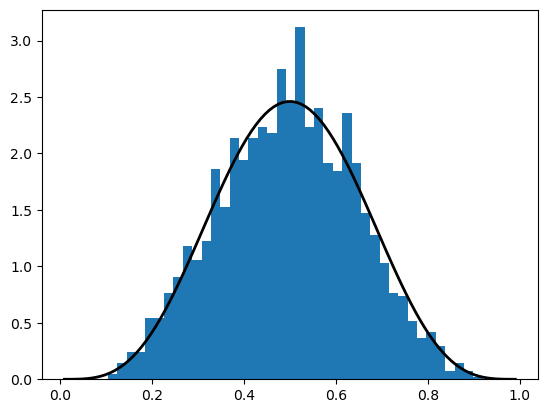

In [8]:
obs = beta.rvs(5, 5, size=2000)
grid = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots()
ax.hist(obs, bins=40, density=True)
ax.plot(grid, beta.pdf(grid, 5, 5), 'k-', linewidth=2)
plt.show()

### چیزهای مفید دیگر در scipy.stats

انواع توابع آماری در `scipy.stats` وجود دارد.

به عنوان مثال، `scipy.stats.linregress` رگرسیون خطی ساده را پیاده‌سازی می‌کند

In [9]:
from scipy.stats import linregress

x = rng.standard_normal(200)
y = 2 * x + 0.1 * rng.standard_normal(200)
gradient, intercept, r_value, p_value, std_err = linregress(x, y)
gradient, intercept

(np.float64(1.9824904678127369), np.float64(0.0010408176111874334))

برای مشاهده لیست کامل، [مستندات](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-functions-scipy-stats) را مشاهده کنید.

## ریشه‌ها و نقاط ثابت

یک **ریشه** یا **صفر** یک تابع حقیقی $f$ در $[a,b]$ یک $x \in [a, b]$ است به طوری که $f(x)=0$.

به عنوان مثال، اگر تابع زیر را رسم کنیم

```{math}
:label: root_f

f(x) = \sin(4 (x - 1/4)) + x + x^{20} - 1
```

با $x \in [0,1]$ به نتیجه زیر می‌رسیم

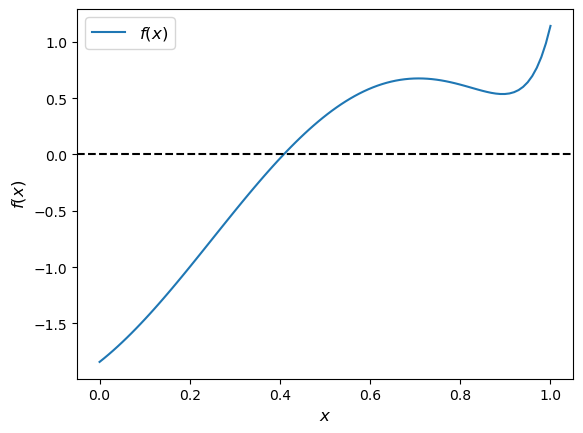

In [10]:
f = lambda x: np.sin(4 * (x - 1/4)) + x + x**20 - 1
x = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
ax.plot(x, f(x), label='$f(x)$')
ax.axhline(ls='--', c='k')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.legend(fontsize=12)
plt.show()

ریشه یکتا تقریباً 0.408 است.

بیایید برخی تکنیک‌های عددی برای یافتن ریشه‌ها را در نظر بگیریم.

### {index}`Bisection <single: Bisection>`

```{index} single: SciPy; Bisection
```

یکی از متداول‌ترین الگوریتم‌ها برای یافتن ریشه عددی، *نصف کردن* است.

برای درک ایده، بازی شناخته شده زیر را به یاد بیاورید که

* بازیکن A به یک عدد مخفی بین 1 و 100 فکر می‌کند
* بازیکن B می‌پرسد آیا کمتر از 50 است
    * اگر بله، B می‌پرسد آیا کمتر از 25 است
    * اگر خیر، B می‌پرسد آیا کمتر از 75 است

و به همین ترتیب.

این همان نصف کردن است.

در اینجا یک پیاده‌سازی ساده از الگوریتم در Python آورده شده است.

برای تمام توابع پیوسته صعودی با رفتار مناسب با $f(a) < 0 < f(b)$ کار می‌کند

(bisect_func)=

In [11]:
def bisect(f, a, b, tol=10e-5):
    """
    Implements the bisection root finding algorithm, assuming that f is a
    real-valued function on [a, b] satisfying f(a) < 0 < f(b).
    """
    lower, upper = a, b

    while upper - lower > tol:
        middle = 0.5 * (upper + lower)
        if f(middle) > 0:   # root is between lower and middle
            lower, upper = lower, middle
        else:               # root is between middle and upper
            lower, upper = middle, upper

    return 0.5 * (upper + lower)

بیایید آن را با استفاده از تابع $f$ تعریف شده در {eq}`root_f` آزمایش کنیم

In [12]:
bisect(f, 0, 1)

0.408294677734375

جای تعجب نیست که SciPy تابع نصف کردن خود را ارائه می‌دهد.

بیایید آن را با استفاده از همان تابع $f$ تعریف شده در {eq}`root_f` آزمایش کنیم

In [13]:
from scipy.optimize import bisect

bisect(f, 0, 1)

0.4082935042806639

### روش {index}`Newton-Raphson Method <single: Newton-Raphson Method>`

```{index} single: SciPy; Newton-Raphson Method
```

یکی دیگر از الگوریتم‌های بسیار متداول یافتن ریشه، [روش نیوتن-رافسون](https://en.wikipedia.org/wiki/Newton%27s_method) است.

در SciPy این الگوریتم توسط `scipy.optimize.newton` پیاده‌سازی شده است.

برخلاف نصف کردن، روش نیوتن-رافسون از اطلاعات شیب محلی در تلاش برای افزایش سرعت همگرایی استفاده می‌کند.

بیایید این را با استفاده از همان تابع $f$ تعریف شده در بالا بررسی کنیم.

با یک شرط اولیه مناسب برای جستجو، همگرایی به دست می‌آید:

In [14]:
from scipy.optimize import newton

newton(f, 0.2)   # Start the search at initial condition x = 0.2

np.float64(0.40829350427935673)

اما شرایط اولیه دیگر منجر به شکست در همگرایی می‌شوند:

In [15]:
newton(f, 0.7)   # Start the search at x = 0.7 instead

np.float64(0.7001700000000279)

### روش‌های ترکیبی

یک اصل کلی روش‌های عددی به شرح زیر است:

* اگر دانش خاصی درباره یک مسئله معین دارید، ممکن است بتوانید از آن برای ایجاد کارایی بهره‌برداری کنید.
* اگر نه، انتخاب الگوریتم شامل یک مبادله بین سرعت و استحکام است.

در عمل، اکثر الگوریتم‌های پیش‌فرض برای یافتن ریشه، بهینه‌سازی و نقاط ثابت از روش‌های *ترکیبی* استفاده می‌کنند.

این روش‌ها معمولاً یک روش سریع را با یک روش قوی به روش زیر ترکیب می‌کنند:

1. سعی کنید از یک روش سریع استفاده کنید
1. تشخیص‌ها را بررسی کنید
1. اگر تشخیص‌ها بد باشند، به یک الگوریتم قوی‌تر تبدیل شوید

در `scipy.optimize`، تابع `brentq` چنین روش ترکیبی است و یک پیش‌فرض خوب

In [16]:
from scipy.optimize import brentq

brentq(f, 0, 1)

0.40829350427936706

اینجا راه‌حل صحیح یافت می‌شود و سرعت بهتر از نصف کردن است:

In [17]:
with qe.Timer(unit="milliseconds"):
    brentq(f, 0, 1)

0.0336 ms elapsed


In [18]:
with qe.Timer(unit="milliseconds"):
    bisect(f, 0, 1)

0.0794 ms elapsed


### یافتن ریشه چند متغیره

```{index} single: SciPy; Multivariate Root-Finding
```

از `scipy.optimize.fsolve` استفاده کنید، یک wrapper برای یک روش ترکیبی در MINPACK.

برای جزئیات [مستندات](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html) را ببینید.

### نقاط ثابت

یک **نقطه ثابت** یک تابع حقیقی $f$ در $[a,b]$ یک $x \in [a, b]$ است به طوری که $f(x)=x$.

```{index} single: SciPy; Fixed Points
```

SciPy تابعی برای یافتن نقاط ثابت (اسکالر) نیز دارد

In [19]:
from scipy.optimize import fixed_point

fixed_point(lambda x: x**2, 10.0)  # 10.0 is an initial guess

array(1.)

اگر نتایج خوبی نگرفتید، همیشه می‌توانید به یافتن ریشه `brentq` برگردید، زیرا
نقطه ثابت یک تابع $f$ ریشه $g(x) := x - f(x)$ است.

## {index}`Optimization <single: Optimization>`

```{index} single: SciPy; Optimization
```

اکثر بسته‌های عددی فقط توابعی برای *کمینه‌سازی* ارائه می‌دهند.

بیشینه‌سازی را می‌توان با یادآوری این که بیشینه‌کننده یک تابع $f$ در دامنه $D$
کمینه‌کننده $-f$ در $D$ است انجام داد.

کمینه‌سازی ارتباط نزدیکی با یافتن ریشه دارد: برای توابع هموار، بهینه‌های داخلی مطابق با ریشه‌های مشتق اول هستند.

مبادله سرعت/استحکام توصیف شده در بالا نیز با بهینه‌سازی عددی وجود دارد.

مگر اینکه اطلاعات قبلی داشته باشید که بتوانید از آن بهره‌برداری کنید، معمولاً بهتر است از روش‌های ترکیبی استفاده کنید.

برای کمینه‌سازی تک متغیره (یعنی اسکالر) محدود، یک گزینه ترکیبی خوب `fminbound` است

In [20]:
from scipy.optimize import fminbound

fminbound(lambda x: x**2, -1, 2)  # Search in [-1, 2]

np.float64(0.0)

### بهینه‌سازی چند متغیره

```{index} single: Optimization; Multivariate
```

بهینه‌سازهای محلی چند متغیره شامل `minimize`، `fmin`، `fmin_powell`، `fmin_cg`، `fmin_bfgs` و `fmin_ncg` هستند.

بهینه‌سازهای محلی چند متغیره محدود شامل `fmin_l_bfgs_b`، `fmin_tnc`، `fmin_cobyla` هستند.

برای جزئیات [مستندات](https://docs.scipy.org/doc/scipy/reference/optimize.html) را ببینید.

## {index}`Integration <single: Integration>`

```{index} single: SciPy; Integration
```

اکثر روش‌های انتگرال‌گیری عددی با محاسبه انتگرال یک چندجمله‌ای تقریبی کار می‌کنند.

خطای حاصل به این بستگی دارد که چندجمله‌ای چقدر به انتگرال‌گیرنده "متناسب" باشد، که به نوبه خود بستگی به این دارد که انتگرال‌گیرنده چقدر "منظم" است.

در SciPy، ماژول مربوطه برای انتگرال‌گیری عددی `scipy.integrate` است.

یک پیش‌فرض خوب برای انتگرال‌گیری تک متغیره `quad` است

In [21]:
from scipy.integrate import quad

integral, error = quad(lambda x: x**2, 0, 1)
integral

0.33333333333333337

در واقع، `quad` یک رابط برای یک روال بسیار استاندارد انتگرال‌گیری عددی در کتابخانه Fortran به نام QUADPACK است.

از [کادراتور Clenshaw-Curtis](https://en.wikipedia.org/wiki/Clenshaw-Curtis_quadrature) استفاده می‌کند که مبتنی بر بسط بر حسب چندجمله‌ای‌های Chebychev است.

گزینه‌های دیگری نیز برای انتگرال‌گیری تک متغیره وجود دارد---یک گزینه مفید `fixed_quad` است که سریع است و بنابراین در داخل حلقه‌های `for` به خوبی کار می‌کند.

توابعی نیز برای انتگرال‌گیری چند متغیره وجود دارد.

برای جزئیات بیشتر [مستندات](https://docs.scipy.org/doc/scipy/reference/integrate.html) را ببینید.

## {index}`Linear Algebra <single: Linear Algebra>`

```{index} single: SciPy; Linear Algebra
```

دیدیم که NumPy ماژولی برای جبر خطی به نام `linalg` ارائه می‌دهد.

SciPy نیز ماژولی برای جبر خطی با همان نام ارائه می‌دهد.

دومی یک زیرمجموعه دقیق از اولی نیست، اما به طور کلی عملکرد بیشتری دارد.

ما به شما می‌گذاریم که [مجموعه روال‌های موجود](https://docs.scipy.org/doc/scipy/reference/linalg.html) را بررسی کنید.

## تمرین‌ها

چند تمرین اول مربوط به قیمت‌گذاری یک اختیار خرید اروپایی تحت
فرض خنثی بودن ریسک است. قیمت صدق می‌کند

$$
P = \beta^n \mathbb E \max\{ S_n - K, 0 \}
$$

که در آن

1. $\beta$ یک عامل تنزیل است،
2. $n$ تاریخ انقضا است،
2. $K$ قیمت اعمال است و
3. $\{S_t\}$ قیمت دارایی پایه در هر زمان $t$ است.

به عنوان مثال، اگر اختیار خرید برای خرید سهام در آمازون با قیمت اعمال $K$ باشد، مالک این حق (اما نه تعهد) را دارد که 1 سهم در آمازون را با قیمت $K$ پس از $n$ روز بخرد.

بنابراین بازده $\max\{S_n - K, 0\}$ است

قیمت، امید ریاضی بازده است که به ارزش فعلی تنزیل شده است.


```{exercise-start}
:label: sp_ex01
```

فرض کنید $S_n$ دارای توزیع [لگ-نرمال](https://en.wikipedia.org/wiki/Log-normal_distribution) با پارامترهای $\mu$ و $\sigma$ است. فرض کنید $f$ نشان‌دهنده چگالی این توزیع باشد. آنگاه

$$
P = \beta^n \int_0^\infty \max\{x - K, 0\} f(x) dx
$$

تابع زیر را رسم کنید

$$
g(x) = \beta^n  \max\{x - K, 0\} f(x)
$$ 

در بازه $[0, 400]$ وقتی `μ, σ, β, n, K = 4, 0.25, 0.99, 10, 40`.

```{hint}
:class: dropdown

از `scipy.stats` می‌توانید `lognorm` را import کنید و سپس از `lognorm.pdf(x, σ, scale=np.exp(μ))` برای به دست آوردن چگالی $f$ استفاده کنید.
```

```{exercise-end}
```

```{solution-start} sp_ex01
:class: dropdown
```

در اینجا یک راه‌حل ممکن آورده شده است

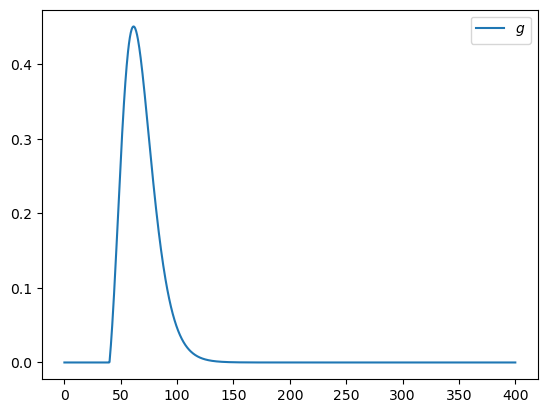

In [22]:
from scipy.integrate import quad
from scipy.stats import lognorm

μ, σ, β, n, K = 4, 0.25, 0.99, 10, 40

def g(x):
    return β**n * np.maximum(x - K, 0) * lognorm.pdf(x, σ, scale=np.exp(μ))

x_grid = np.linspace(0, 400, 1000)
y_grid = g(x_grid) 

fig, ax = plt.subplots()
ax.plot(x_grid, y_grid, label="$g$")
ax.legend()
plt.show()

```{solution-end}
```

```{exercise}
:label: sp_ex02

برای به دست آوردن قیمت اختیار، انتگرال این تابع را به صورت عددی با استفاده از `quad` از `scipy.integrate` محاسبه کنید.

```

```{solution-start} sp_ex02
:class: dropdown
```

In [23]:
P, error = quad(g, 0, 1_000)
print(f"The numerical integration based option price is {P:.3f}")

The numerical integration based option price is 15.188


```{solution-end}
```

```{exercise}
:label: sp_ex03

سعی کنید با استفاده از Monte Carlo برای محاسبه عبارت امید ریاضی در قیمت اختیار، به جای `quad`، به نتیجه مشابهی برسید.

به طور خاص، از این واقعیت استفاده کنید که اگر $S_n^1, \ldots, S_n^M$ نمونه‌های مستقل از
توزیع لگ‌نرمال مشخص شده در بالا باشند، آنگاه، طبق قانون
اعداد بزرگ،

$$ \mathbb E \max\{ S_n - K, 0 \} 
    \approx
    \frac{1}{M} \sum_{m=1}^M \max \{S_n^m - K, 0 \}
    $$
    
`M = 10_000_000` را تنظیم کنید

```

```{solution-start} sp_ex03
:class: dropdown
```

در اینجا یک راه‌حل آورده شده است:

In [24]:
rng = np.random.default_rng()
M = 10_000_000
S = np.exp(μ + σ * rng.standard_normal(M))
return_draws = np.maximum(S - K, 0)
P = β**n * np.mean(return_draws) 
print(f"The Monte Carlo option price is {P:3f}")

The Monte Carlo option price is 15.185921


```{solution-end}
```



```{exercise}
:label: sp_ex1

در {ref}`این سخنرانی <functions>`، ما مفهوم {ref}`فراخوانی تابع بازگشتی <recursive_functions>` را مورد بحث قرار دادیم.

سعی کنید یک پیاده‌سازی بازگشتی از تابع نصف کردن خانگی {ref}`توصیف شده در بالا <bisect_func>` بنویسید.

آن را روی تابع {eq}`root_f` آزمایش کنید.
```

```{solution-start} sp_ex1
:class: dropdown
```

در اینجا یک راه‌حل معقول آورده شده است:

In [25]:
def bisect(f, a, b, tol=10e-5):
    """
    Implements the bisection root-finding algorithm, assuming that f is a
    real-valued function on [a, b] satisfying f(a) < 0 < f(b).
    """
    lower, upper = a, b
    if upper - lower < tol:
        return 0.5 * (upper + lower)
    else:
        middle = 0.5 * (upper + lower)
        print(f'Current mid point = {middle}')
        if f(middle) > 0:   # Implies root is between lower and middle
            return bisect(f, lower, middle)
        else:               # Implies root is between middle and upper
            return bisect(f, middle, upper)

می‌توانیم آن را به صورت زیر آزمایش کنیم

In [26]:
f = lambda x: np.sin(4 * (x - 0.25)) + x + x**20 - 1
bisect(f, 0, 1)

Current mid point = 0.5
Current mid point = 0.25
Current mid point = 0.375
Current mid point = 0.4375
Current mid point = 0.40625
Current mid point = 0.421875
Current mid point = 0.4140625
Current mid point = 0.41015625
Current mid point = 0.408203125
Current mid point = 0.4091796875
Current mid point = 0.40869140625
Current mid point = 0.408447265625
Current mid point = 0.4083251953125
Current mid point = 0.40826416015625


0.408294677734375

```{solution-end}
```